<>:31: SyntaxWarning: invalid escape sequence '\c'
<>:31: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_14522/3346898098.py:31: SyntaxWarning: invalid escape sequence '\c'
  ax1.plot(X_test, y_pred, color='navy', linewidth=3, label='Polinomsal Tahmin Eğrisi ($3^{\circ}$)')


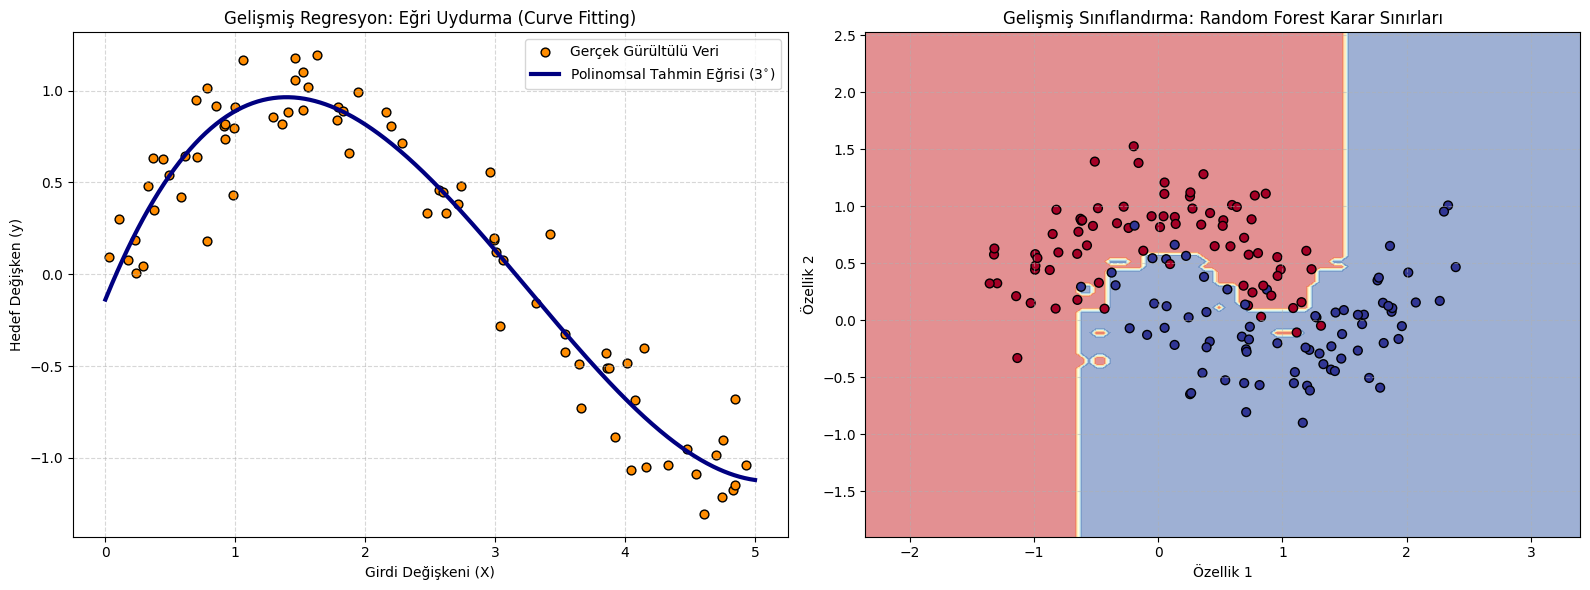

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.inspection import DecisionBoundaryDisplay

# Grafik alanını oluşturma
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ------------------------------------------------------------------
# 1. SOL GRAFİK: DOĞRUSAL OLMAYAN (POLİNOMSAL) REGRESYON
# ------------------------------------------------------------------
np.random.seed(42)
# Dalgalı (Sinüs dalgası benzeri) gürültülü bir veri üretiyoruz
X_reg = np.sort(5 * np.random.rand(80, 1), axis=0)
y_reg = np.sin(X_reg).ravel() + np.random.normal(0, 0.2, X_reg.shape[0])

# 3. dereceden polinomsal regresyon modeli (Verinin kıvrımlarını öğrenmesi için)
poly_model = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())
poly_model.fit(X_reg, y_reg)

# Tahmin eğrisini çizdirmek için test verisi
X_test = np.linspace(0, 5, 500)[:, np.newaxis]
y_pred = poly_model.predict(X_test)

# Çizim
ax1.scatter(X_reg, y_reg, color='darkorange', edgecolor='k', s=40, label='Gerçek Gürültülü Veri')
ax1.plot(X_test, y_pred, color='navy', linewidth=3, label='Polinomsal Tahmin Eğrisi ($3^{\circ}$)')
ax1.set_title('Gelişmiş Regresyon: Eğri Uydurma (Curve Fitting)', fontsize=12)
ax1.set_xlabel('Girdi Değişkeni (X)')
ax1.set_ylabel('Hedef Değişken (y)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# ------------------------------------------------------------------
# 2. SAĞ GRAFİK: DOĞRUSAL OLMAYAN SINIFLANDIRMA (RANDOM FOREST)
# ------------------------------------------------------------------
# Birbirinin içine geçmiş iki ay şekilli (Moons) veri kümesi üretiyoruz
X_cls, y_cls = make_moons(n_samples=150, noise=0.25, random_state=42)

# Esnek ve güçlü bir model olan Random Forest (Rastgele Orman) kullanıyoruz
clf = RandomForestClassifier(max_depth=5, n_estimators=20, random_state=42)
clf.fit(X_cls, y_cls)

# Modelin karmaşık karar sınırını (Decision Boundary) arka plana çizme
DecisionBoundaryDisplay.from_estimator(
    clf, X_cls, response_method="predict",
    cmap=plt.cm.RdYlBu, alpha=0.5, ax=ax2
)

# Veri noktalarını çizme
scatter = ax2.scatter(X_cls[:, 0], X_cls[:, 1], c=y_cls, cmap=plt.cm.RdYlBu, edgecolors='k', s=40)
ax2.set_title('Gelişmiş Sınıflandırma: Random Forest Karar Sınırları', fontsize=12)
ax2.set_xlabel('Özellik 1')
ax2.set_ylabel('Özellik 2')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()